In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# GO enrichment
import gseapy as gp

import os

import scanpy as sc

sc.settings.set_figure_params(
    dpi=300,           
    frameon=False,     
    #figsize=(6, 5),    
    fontsize=16,       
    #format='pdf'     
)

Functions:

## Load data

In [2]:
## filtering protein-coding genes
adata = sc.read_h5ad("../data/data_standard_norm_regress_lncRNA_protein_coding.h5ad")

## Comparison PCA and Diffusion Map UMAPs

PCA:

In [3]:
sc.tl.pca(adata, svd_solver='arpack')

# Original neighbors from PCA
sc.pp.neighbors(
    adata,
    use_rep="X_pca",
    n_neighbors=15,
    n_pcs=13,
    random_state=12,
    key_added="neighbors_pca"
)

# UMAP based on PCA neighbors
sc.tl.umap(
    adata,
    neighbors_key="neighbors_pca",
    random_state=12,
    min_dist=0.1,
    spread=0.75
)

adata.obsm["X_umap_pca"] = adata.obsm["X_umap"].copy()

# Leiden based on PCA neighbors
sc.tl.leiden(
    adata,
    neighbors_key="neighbors_pca",
    resolution=0.3,
    random_state=12,
    key_added="leiden_pca"
)

/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_81006/2973093217.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Diffusion Map:

NOTE => we use lower resolution to match # of Leiden clusters (or similar clusters)

In [4]:
# Diffusion map
sc.tl.diffmap(adata, n_comps=13, neighbors_key="neighbors_pca", random_state=12)

# Neighbors using diffusion components
sc.pp.neighbors(
    adata,
    use_rep="X_diffmap",
    n_neighbors=15,
    random_state=12,
    key_added="neighbors_diffmap"
)

# UMAP based on diffusion neighbors
sc.tl.umap(
    adata,
    neighbors_key="neighbors_diffmap",
    random_state=12,
    min_dist=0.1,
    spread=0.75
)

adata.obsm["X_umap_diffmap"] = adata.obsm["X_umap"].copy()

# Leiden based on diffusion neighbors
sc.tl.leiden(
    adata,
    neighbors_key="neighbors_diffmap",
    resolution=0.1,
    random_state=12,
    key_added="leiden_diffmap"
)

Plot original UMAP with PCA:

In [5]:
plot_embedding(
    adata,
    "X_umap_pca",
    ["leiden_pca", "leiden_diffmap", "diff_protocol"]
)

NameError: name 'plot_embedding' is not defined

Plot original PCA clusters in diffusion map UMAP:

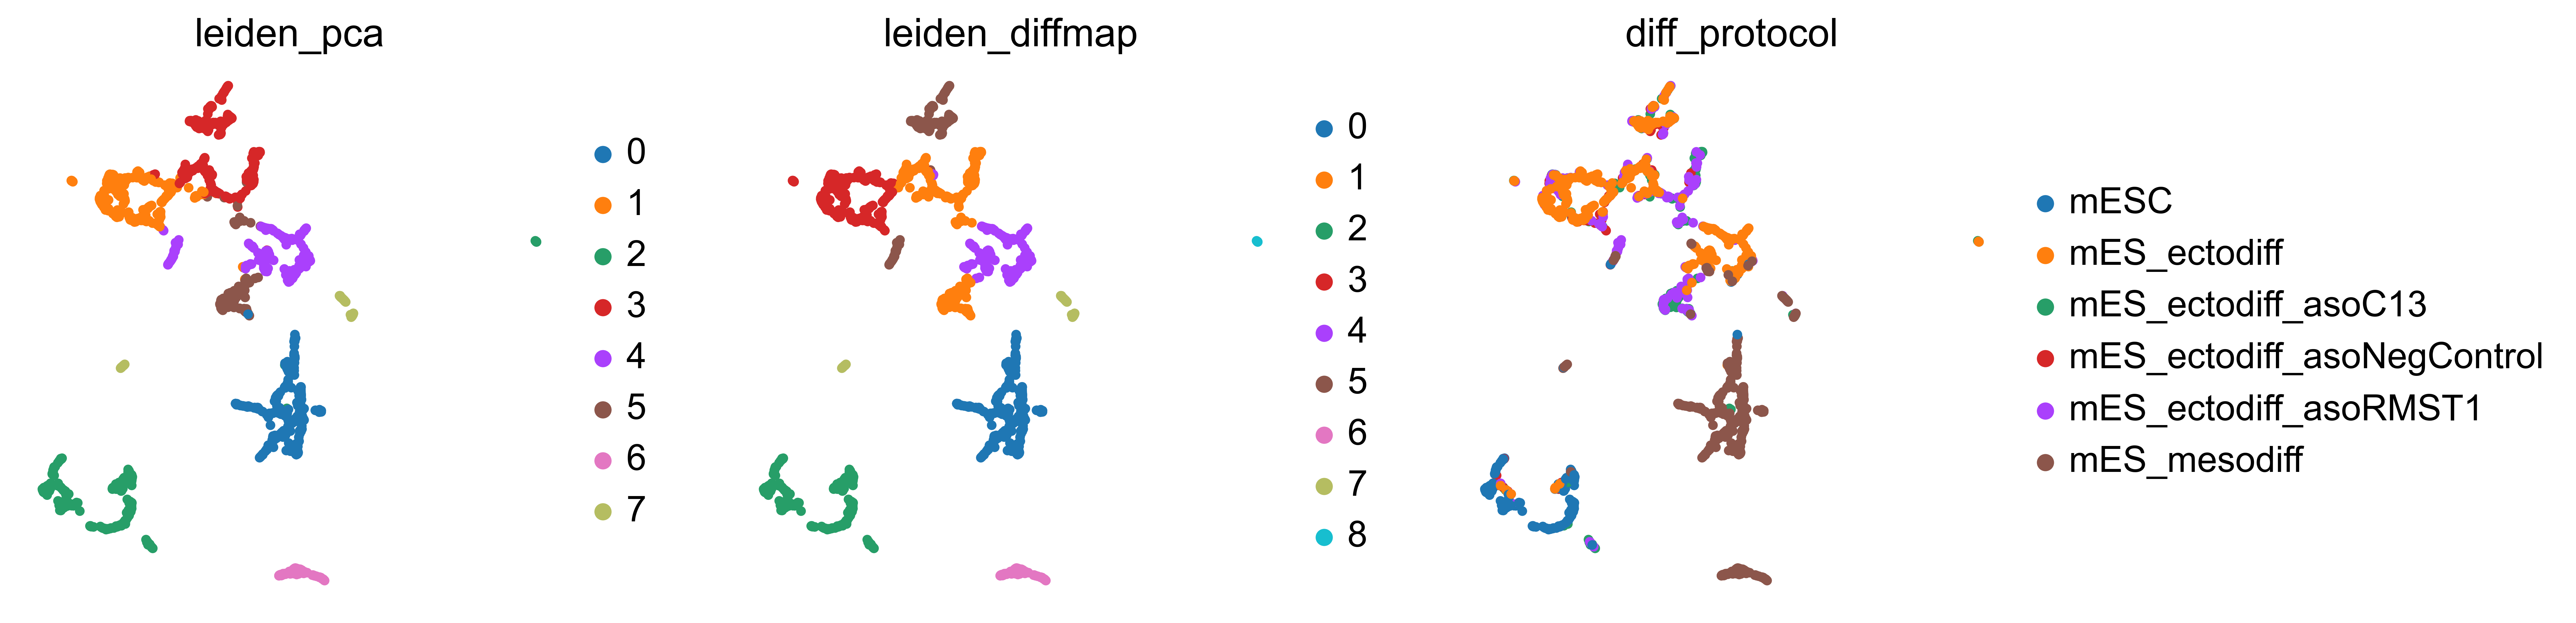

In [ ]:
plot_embedding(
    adata,
    "X_umap_diffmap",
    ["leiden_pca", "leiden_diffmap", "diff_protocol"]
)

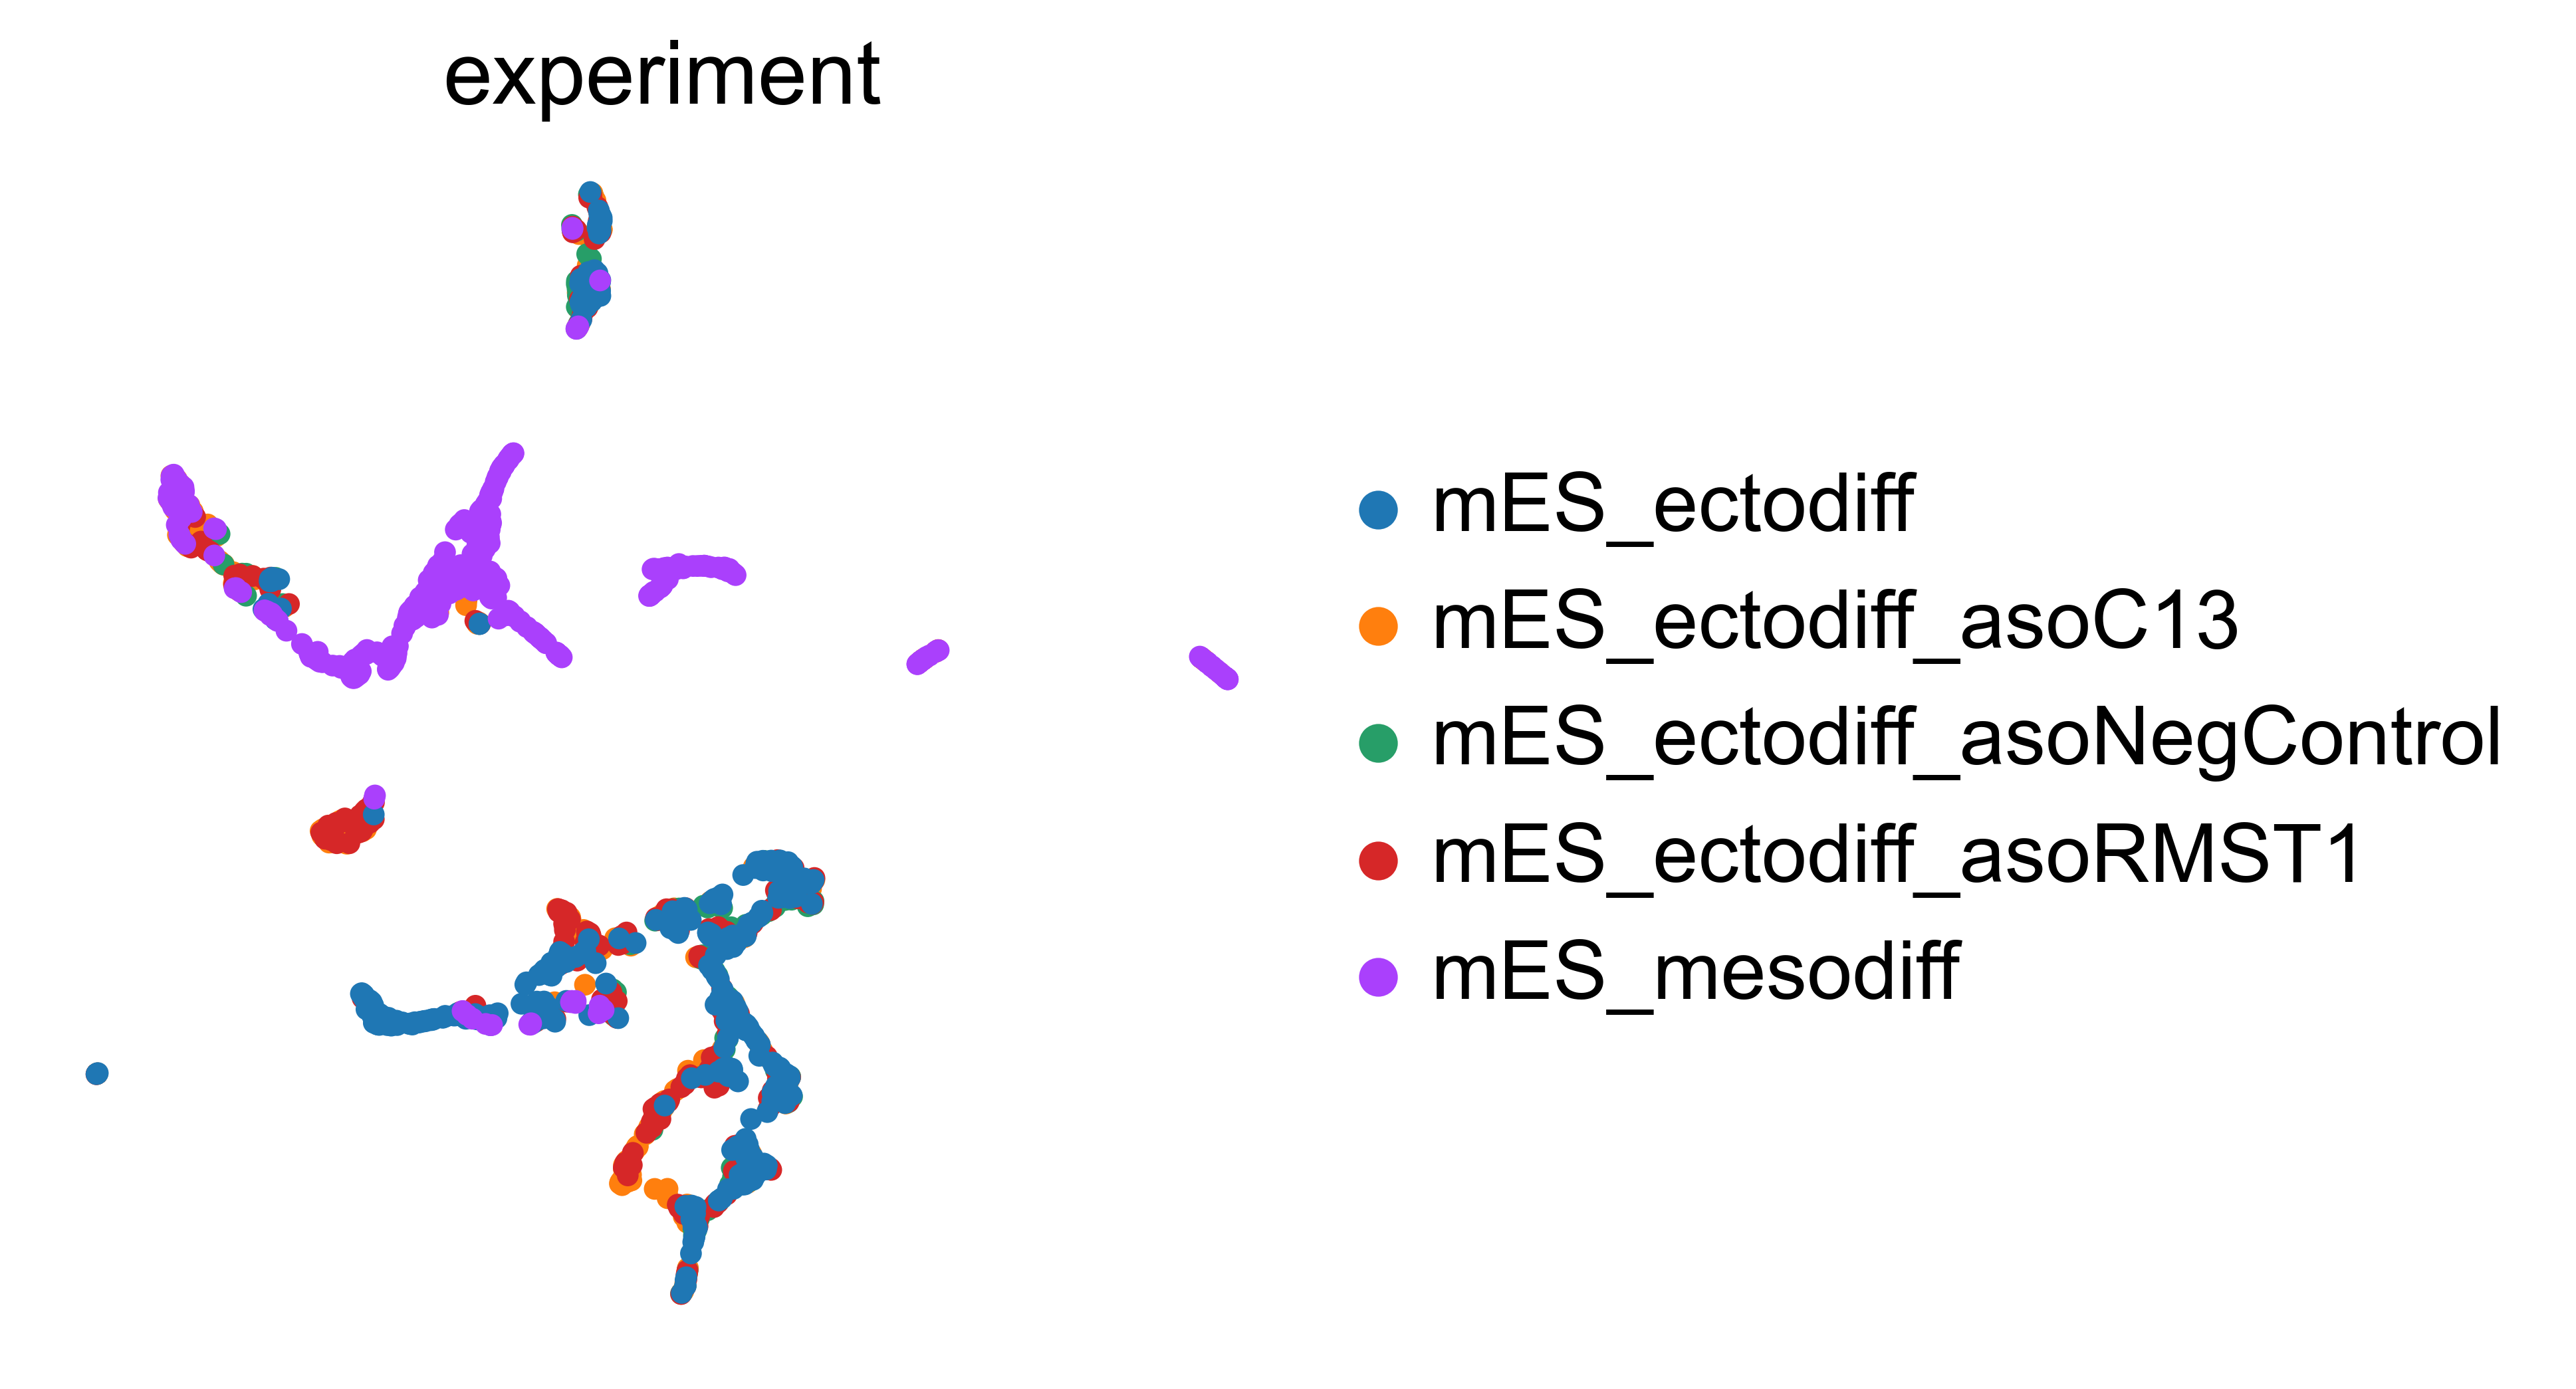

In [ ]:
plot_embedding(
    adata,
    "X_umap_diffmap",
    ["experiment"]
)

## Compare composition per cluster for both approaches

PCA:

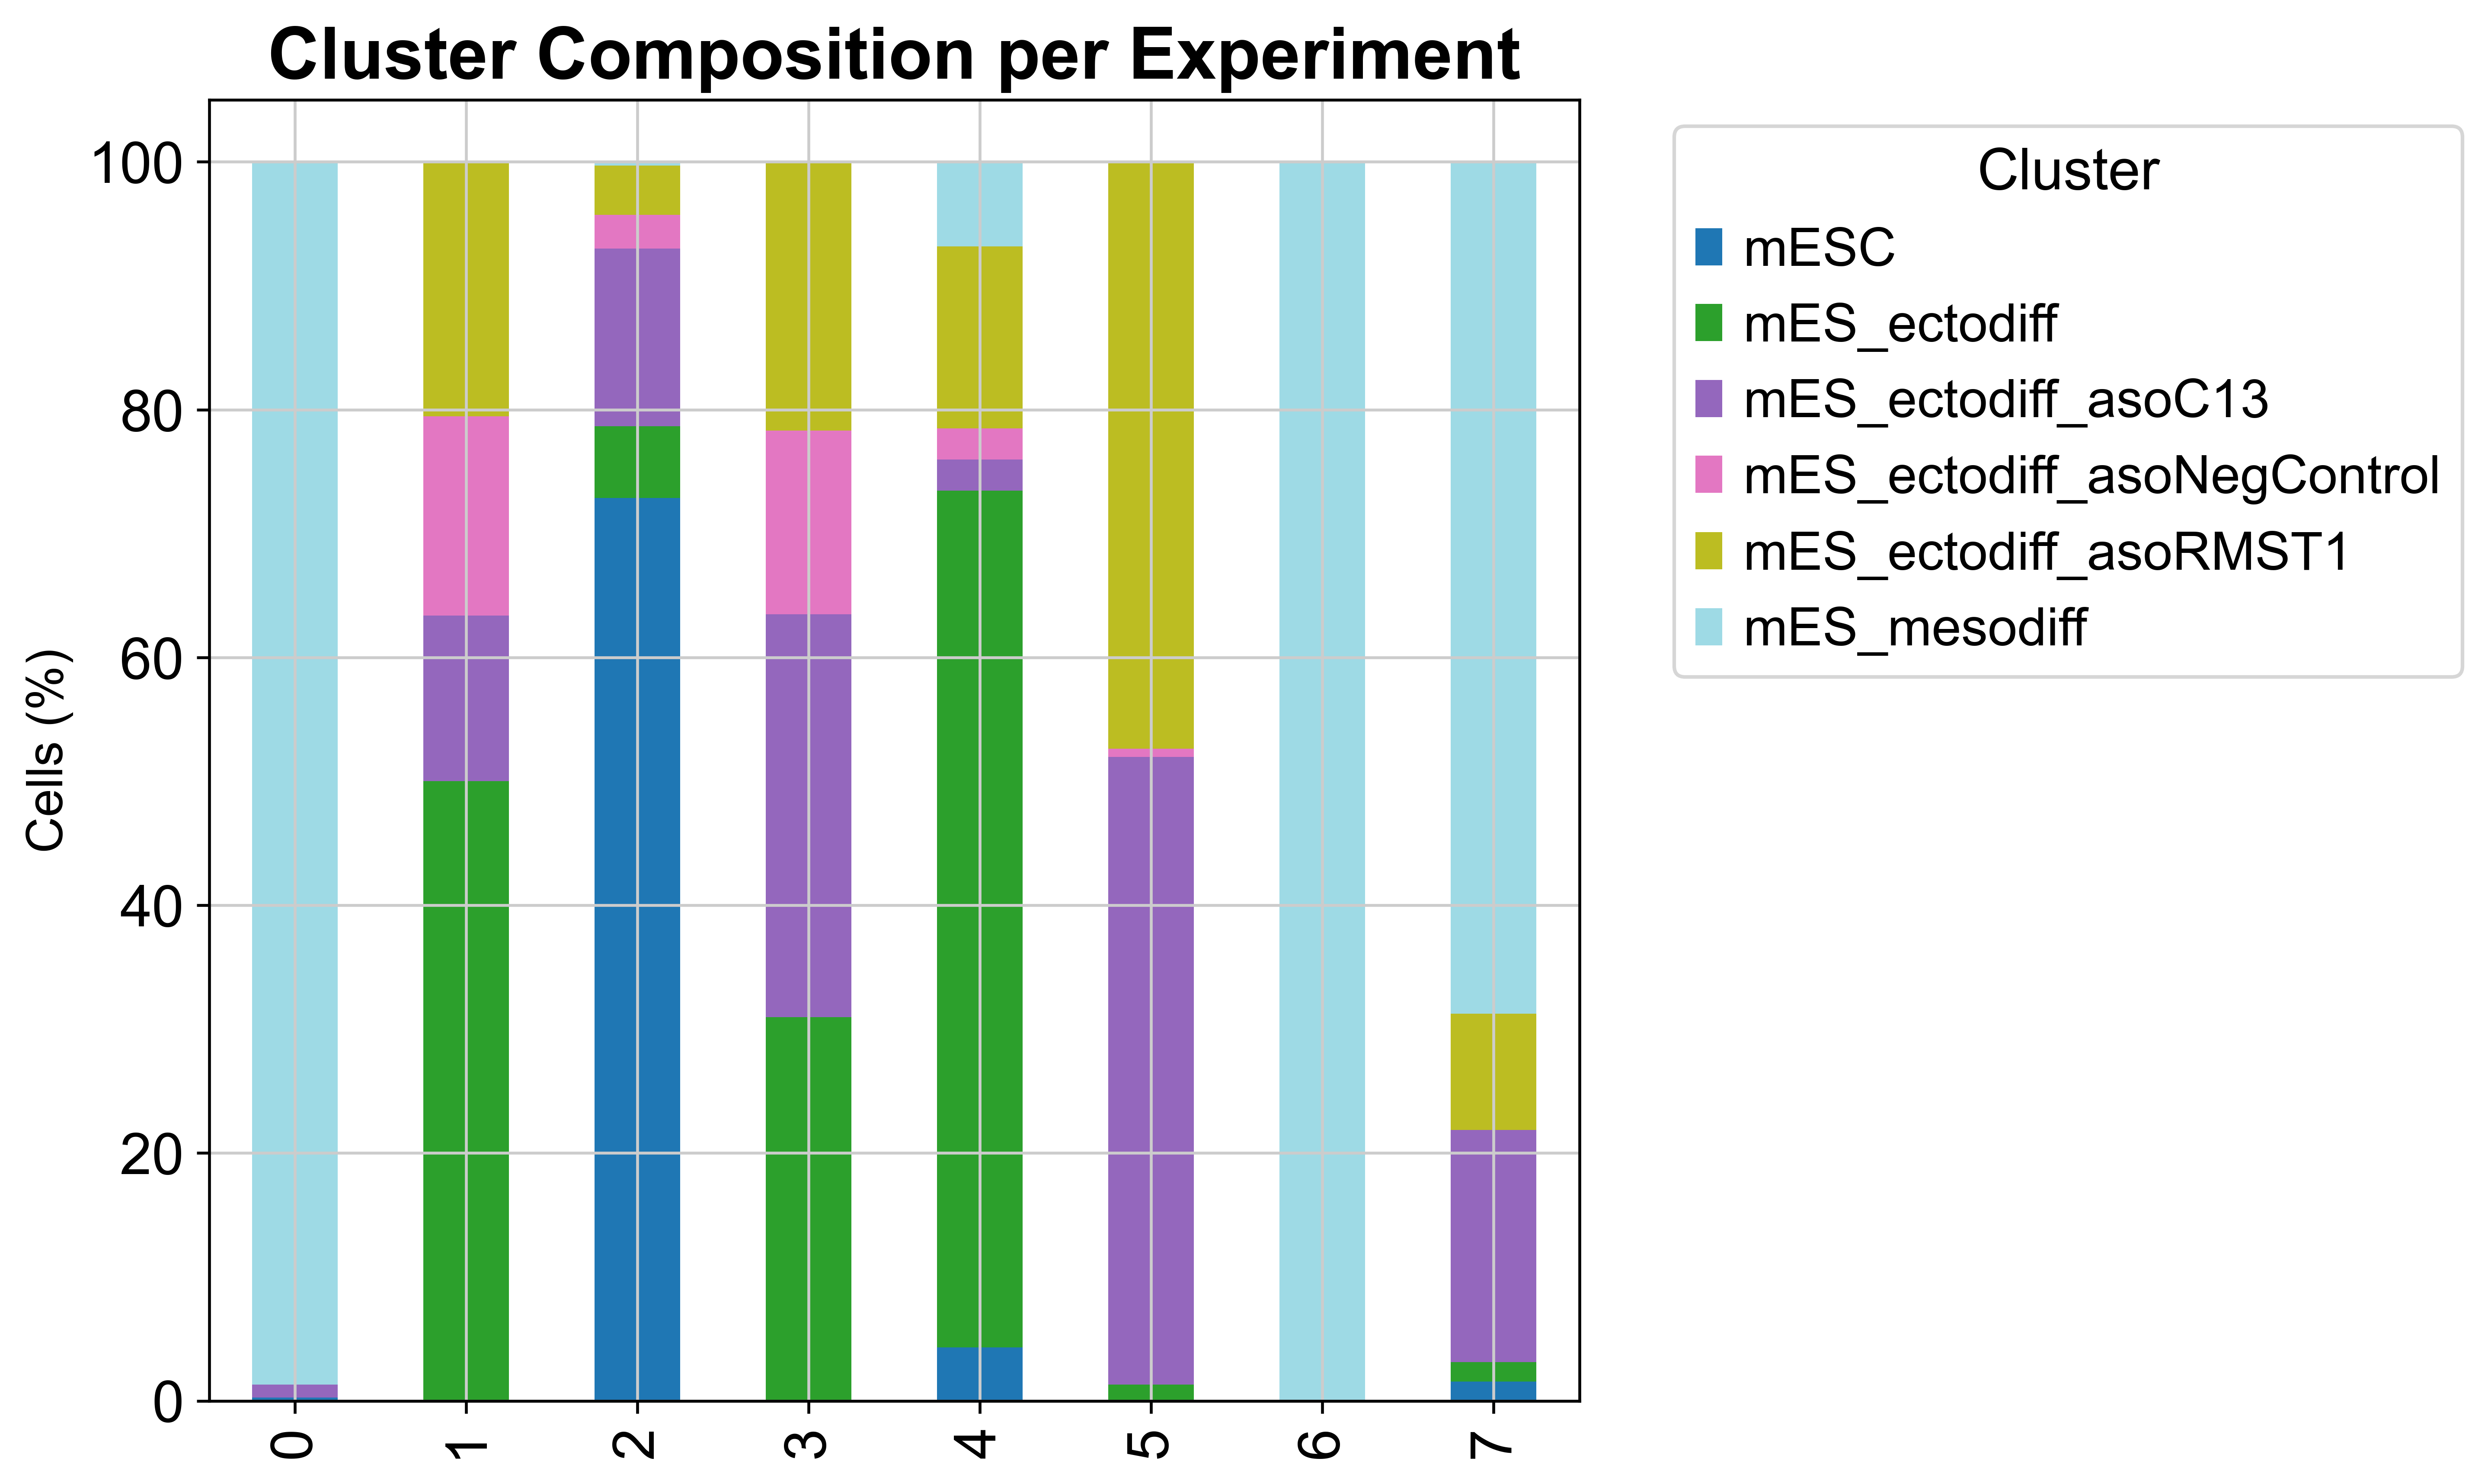

In [ ]:
# Create a crosstab counting how many cells from each experiment are in each cluster
composition = pd.crosstab(adata.obs['leiden_pca'], adata.obs['diff_protocol'], normalize='index') * 100

# Plotting as a stacked bar chart
ax = composition.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("Cluster Composition per Experiment", fontsize=20, fontweight='bold')
plt.ylabel("Cells (%)", fontsize=14)
plt.xlabel("")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Diffusion Map:

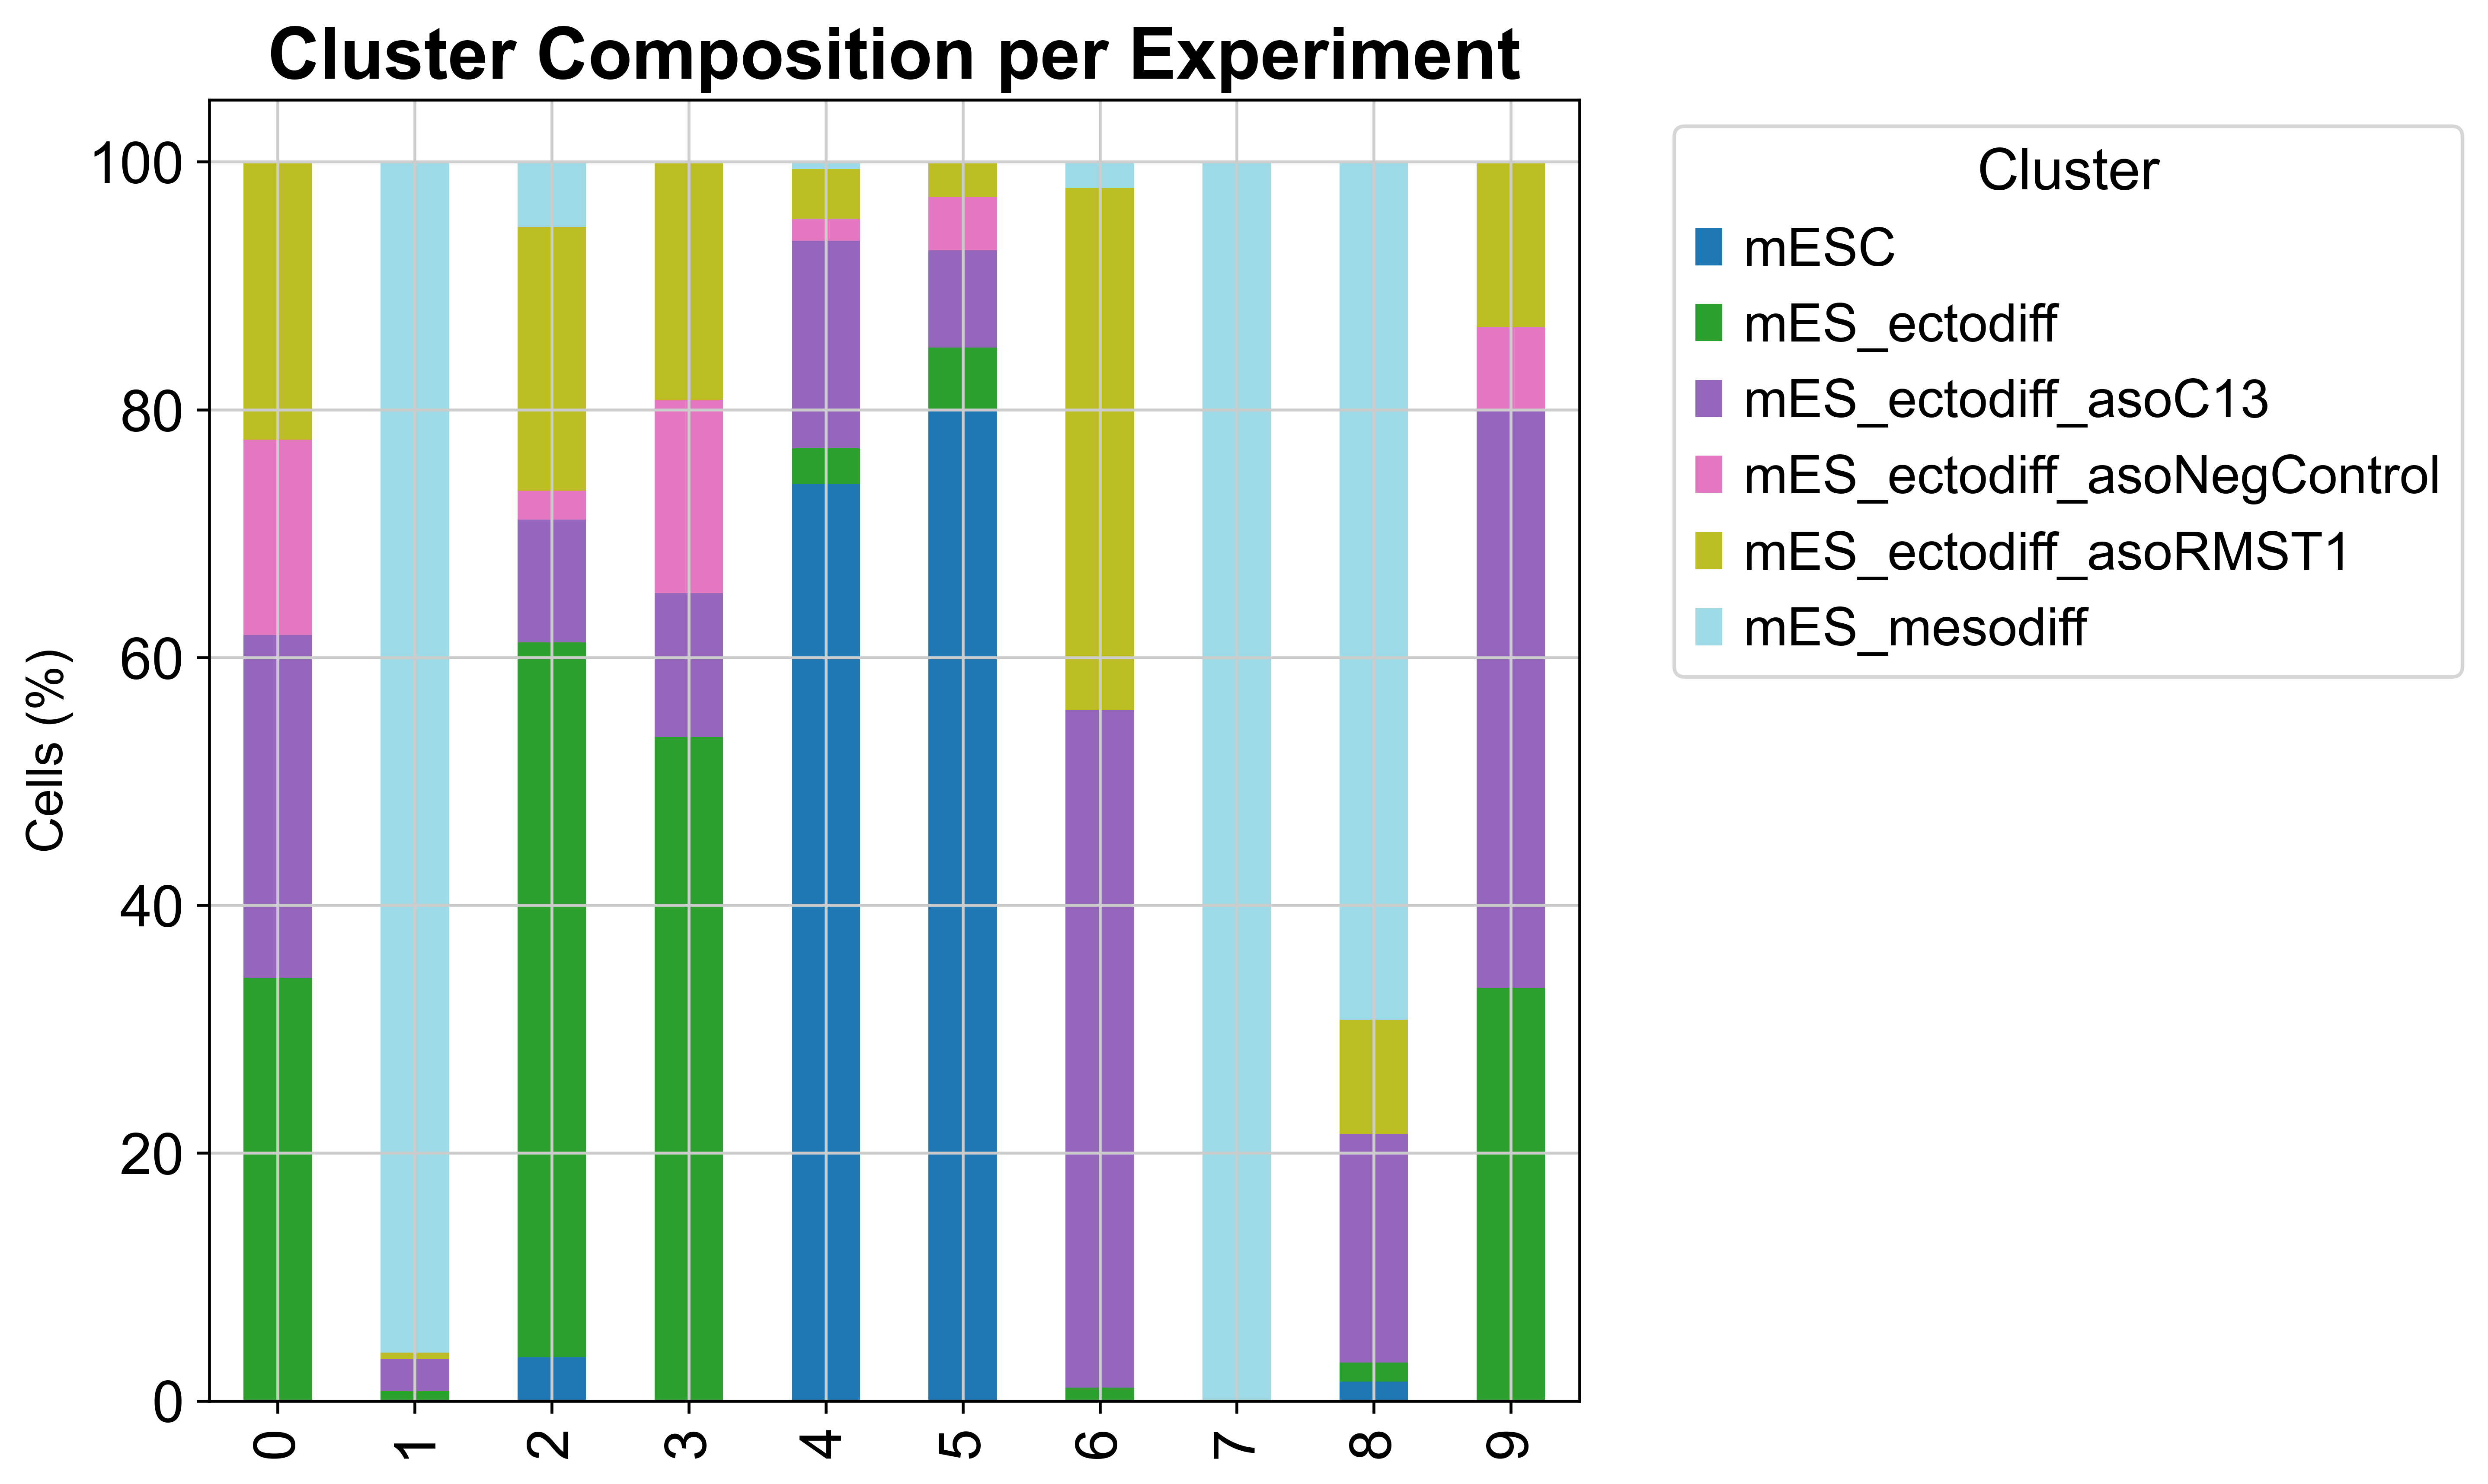

In [ ]:
# Create a crosstab counting how many cells from each experiment are in each cluster
composition = pd.crosstab(adata.obs['leiden_diffmap'], adata.obs['diff_protocol'], normalize='index') * 100

# Plotting as a stacked bar chart
ax = composition.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("Cluster Composition per Experiment", fontsize=20, fontweight='bold')
plt.ylabel("Cells (%)", fontsize=14)
plt.xlabel("")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Check diffusion components

1 vs 2

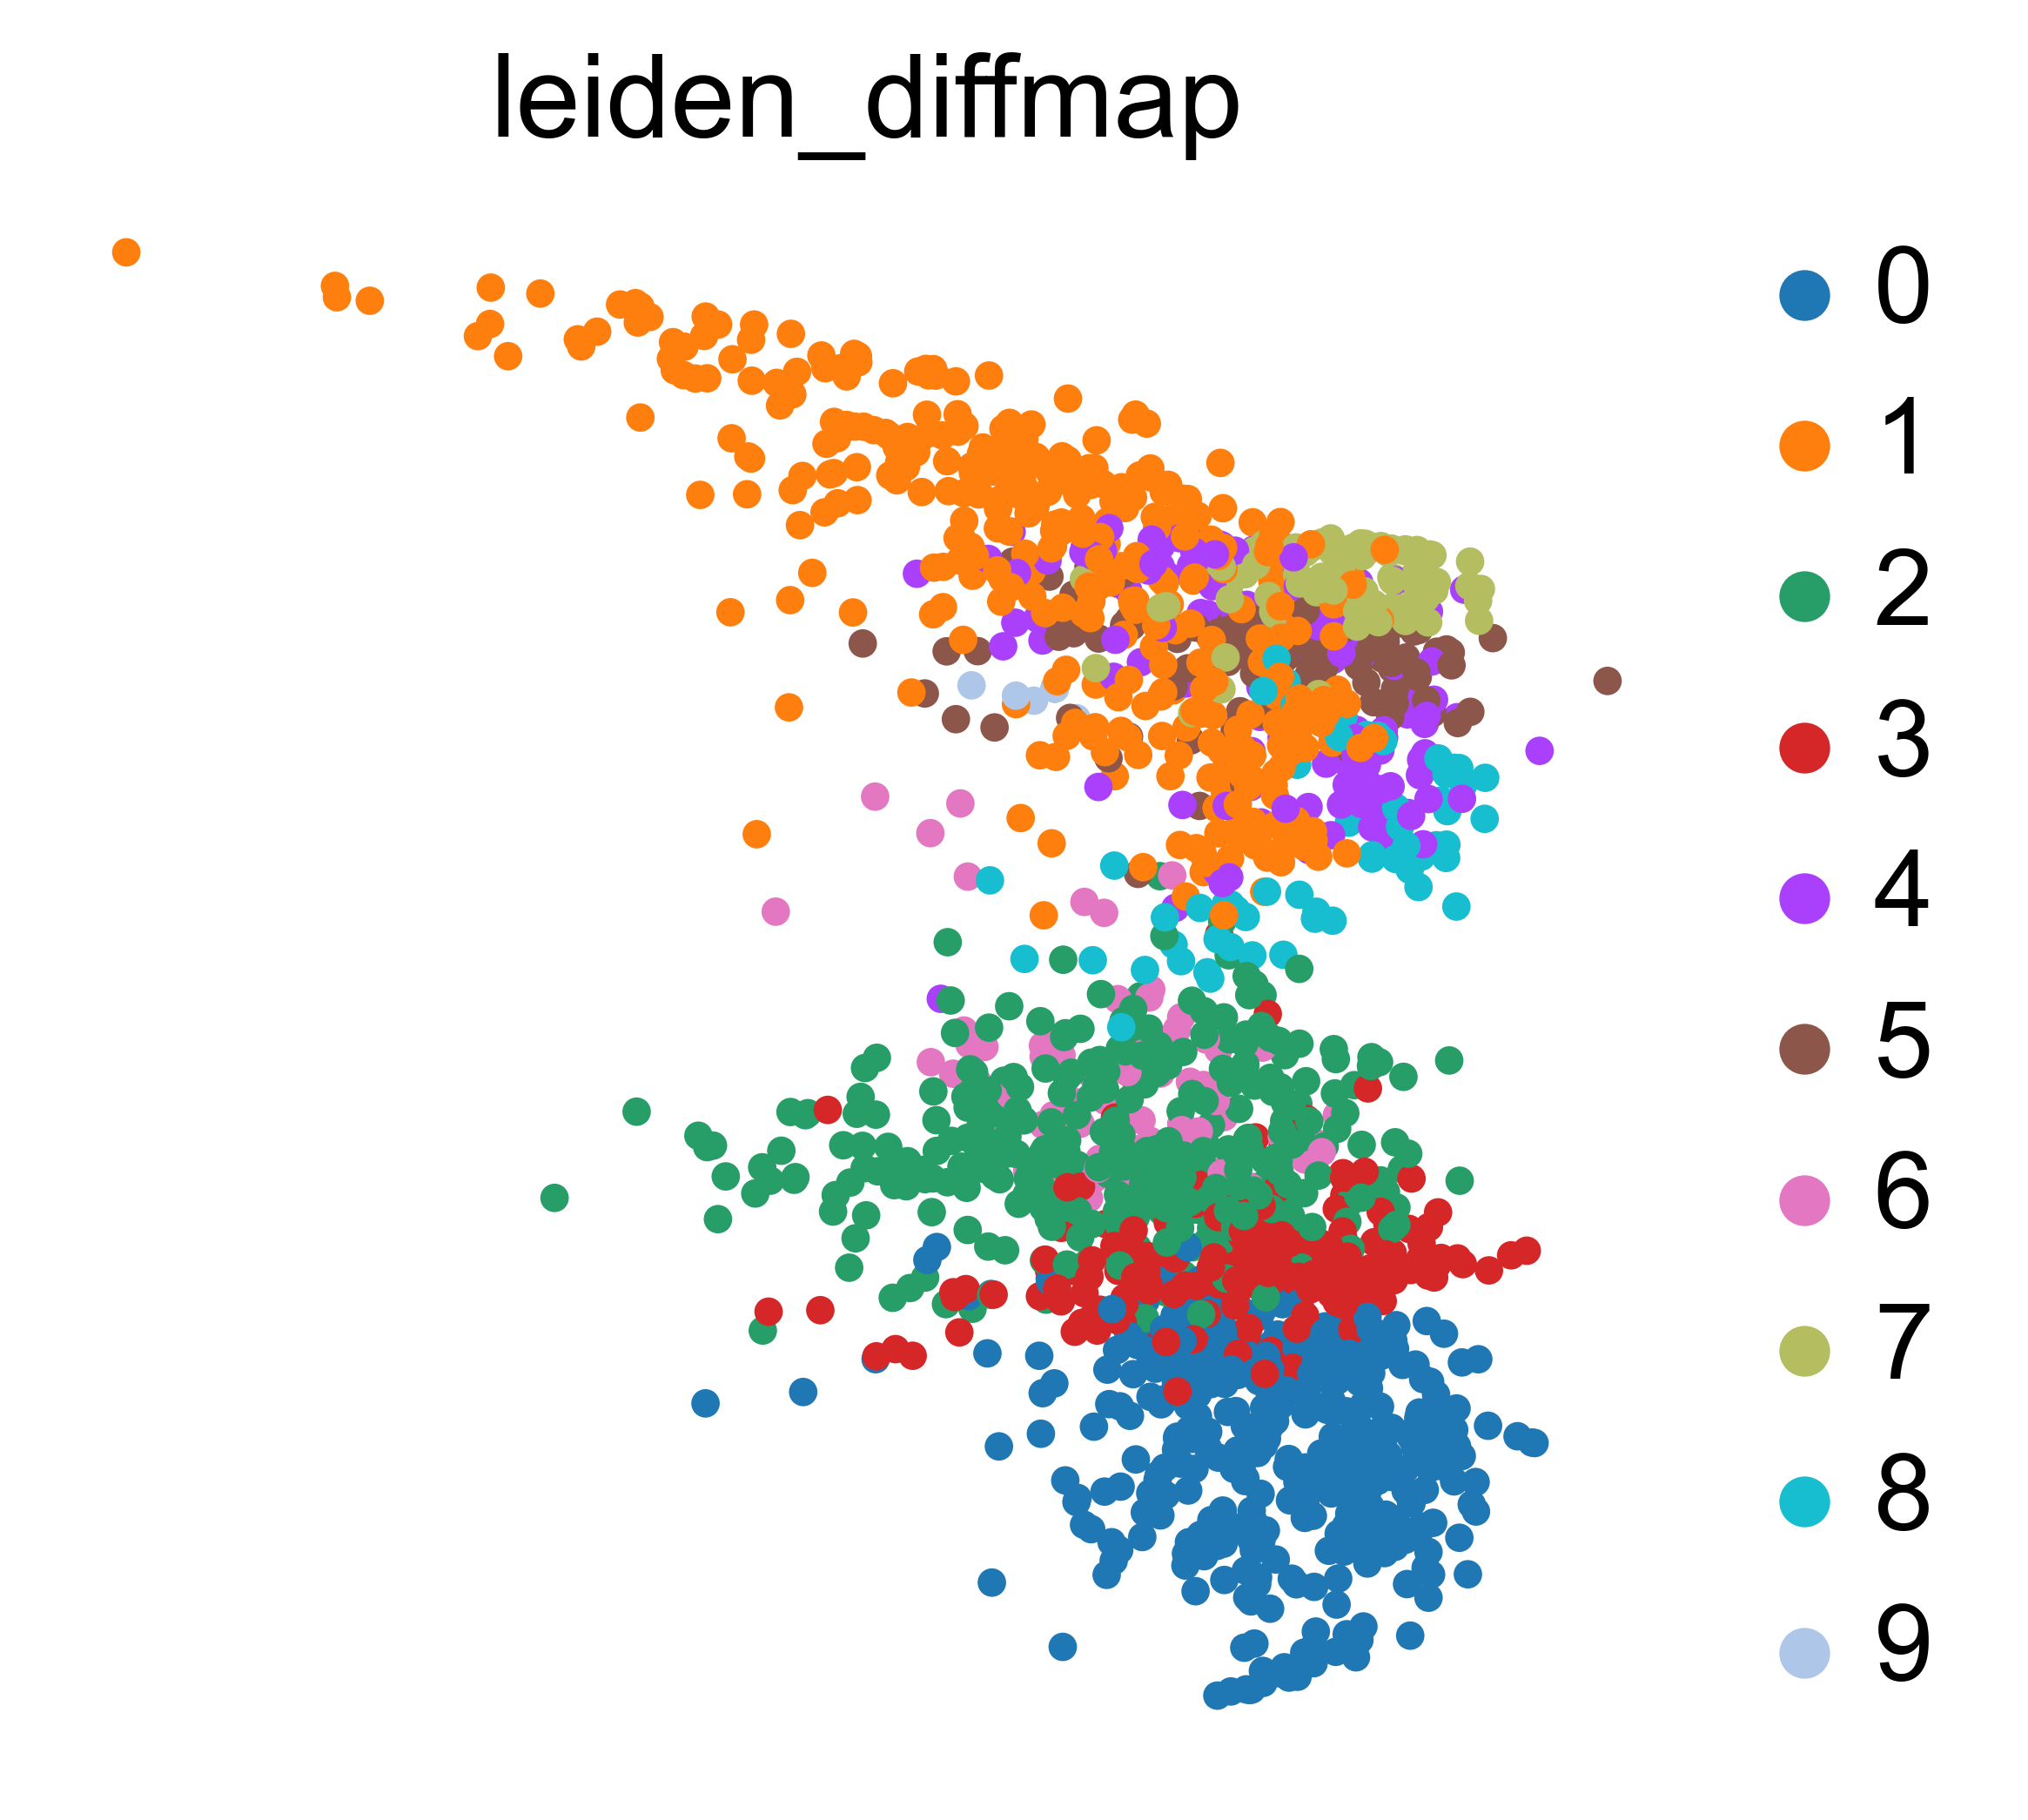

In [ ]:
sc.pl.diffmap(
    adata,
    components=["1,2"],
    color="leiden_diffmap"
)

2 vs 3

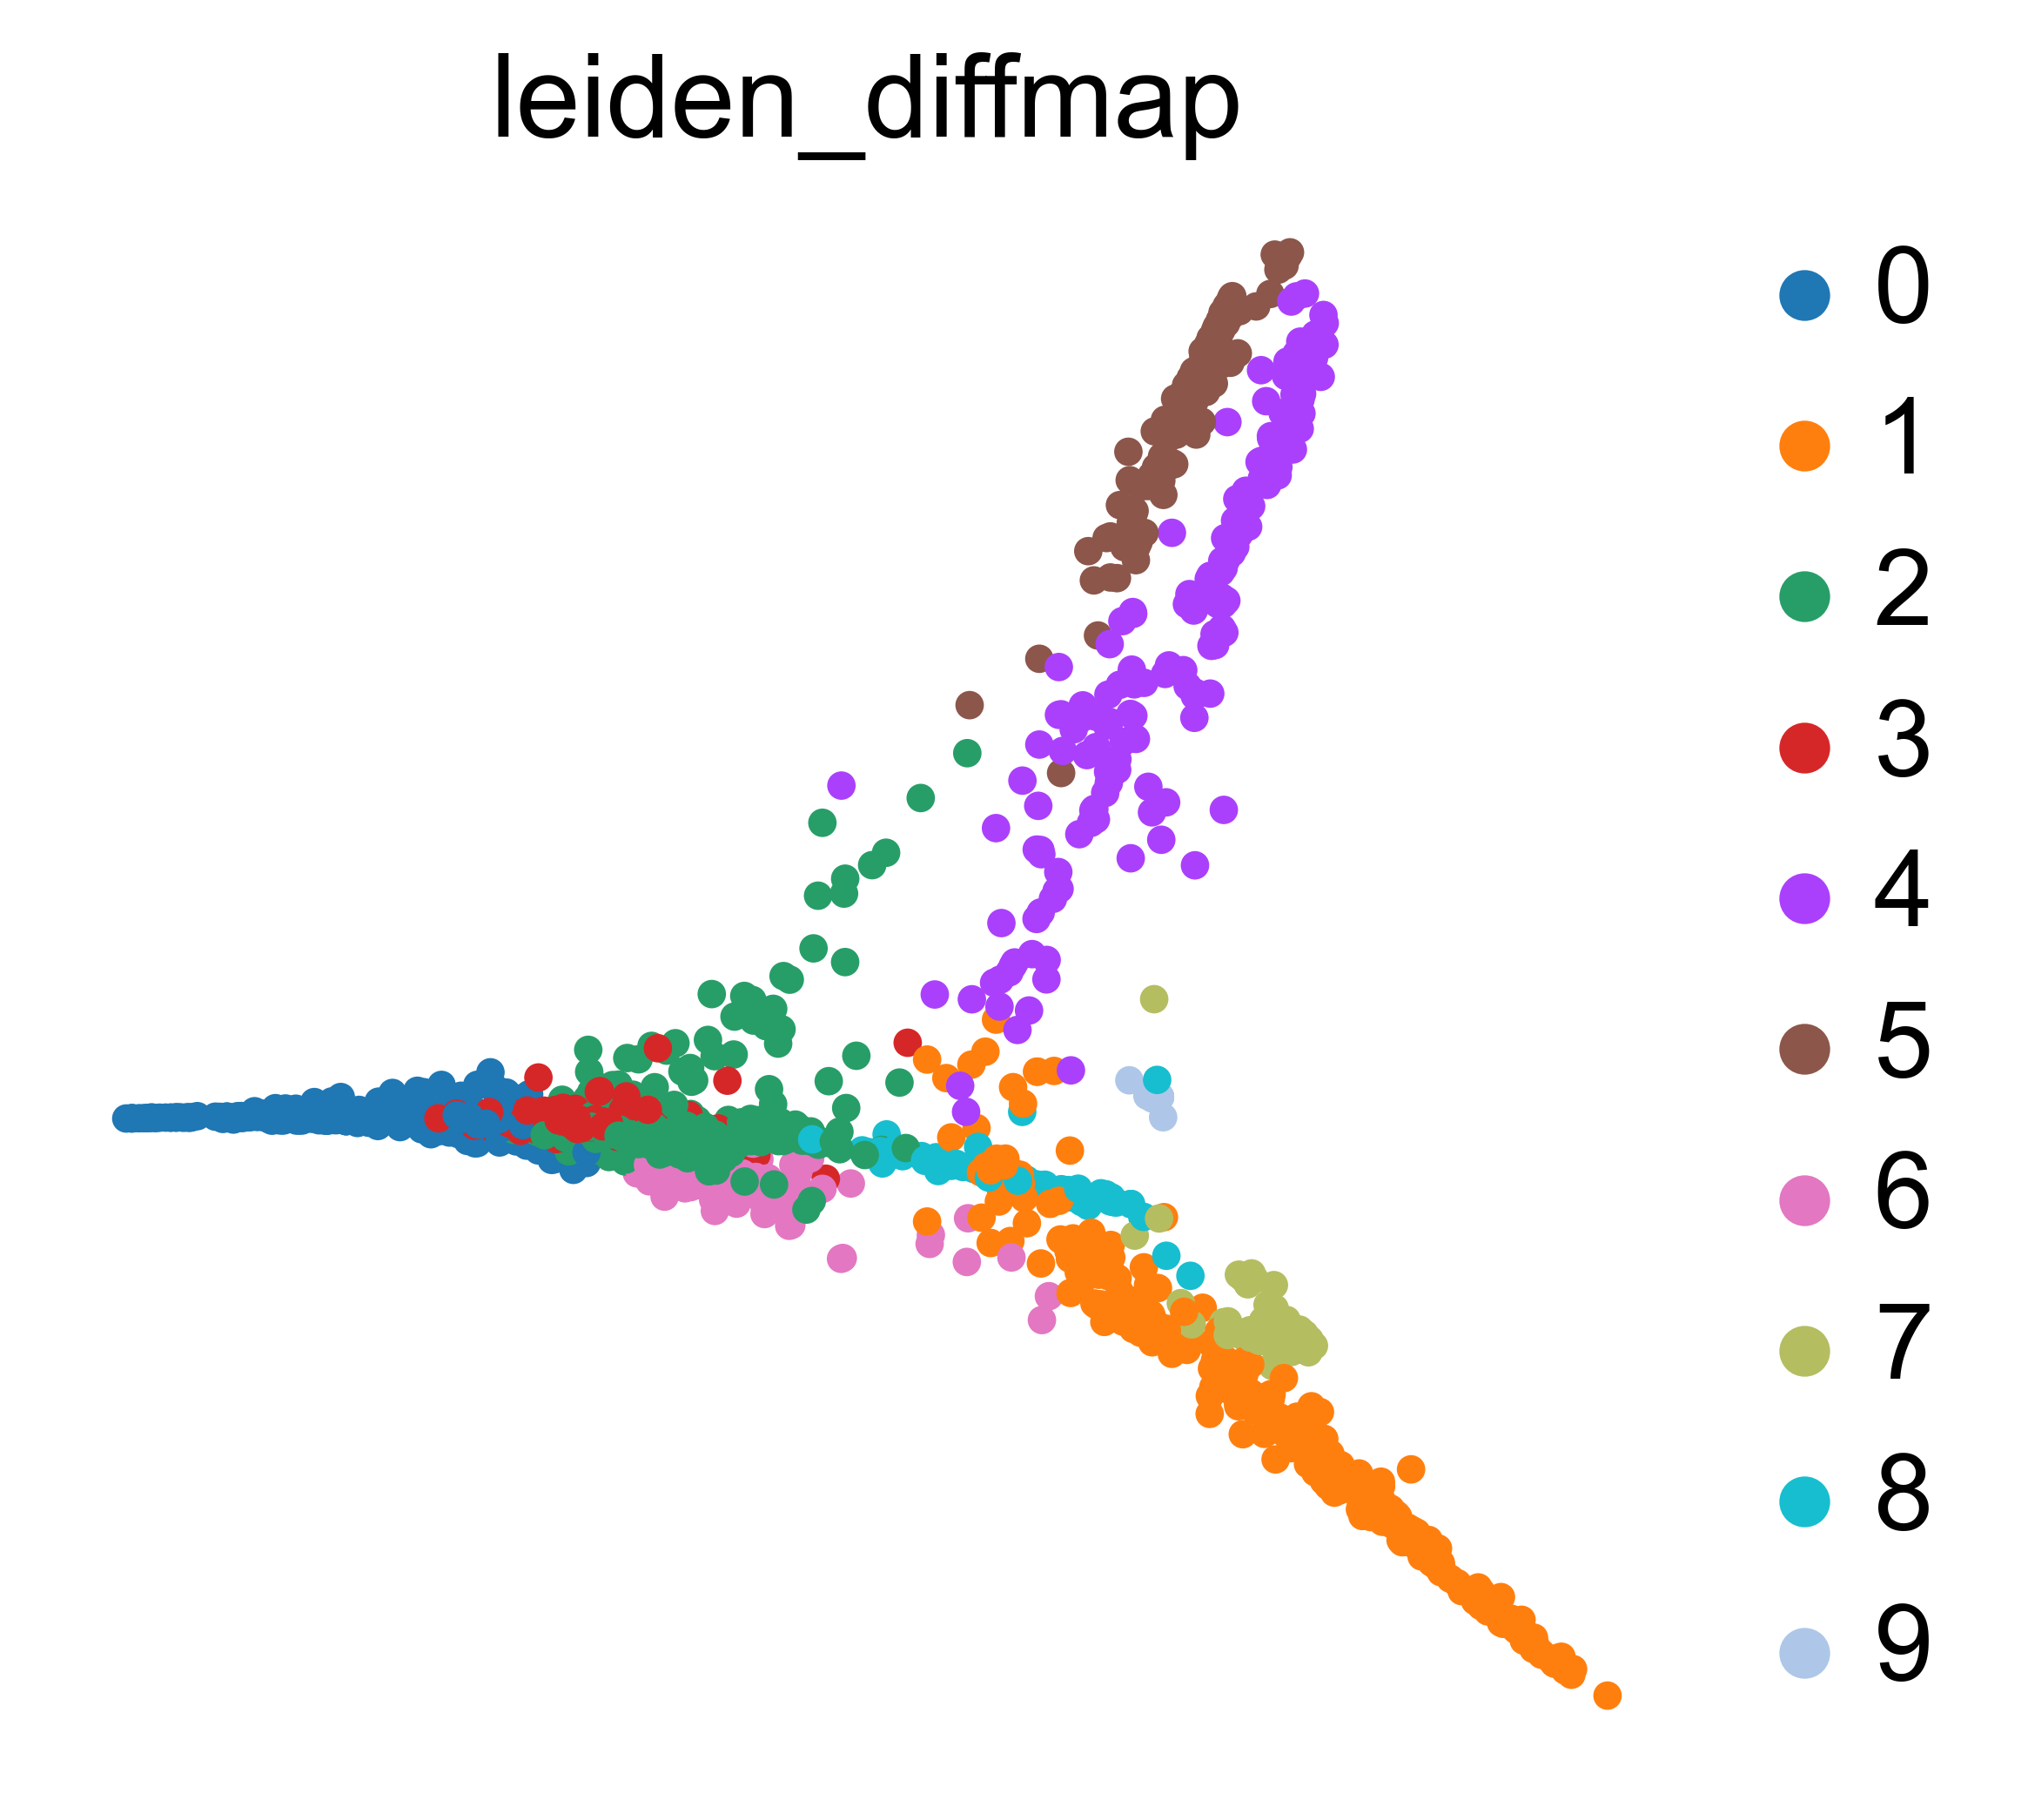

In [ ]:
sc.pl.diffmap(
    adata,
    components=["2,3"],
    color="leiden_diffmap"
)

1 vs 3

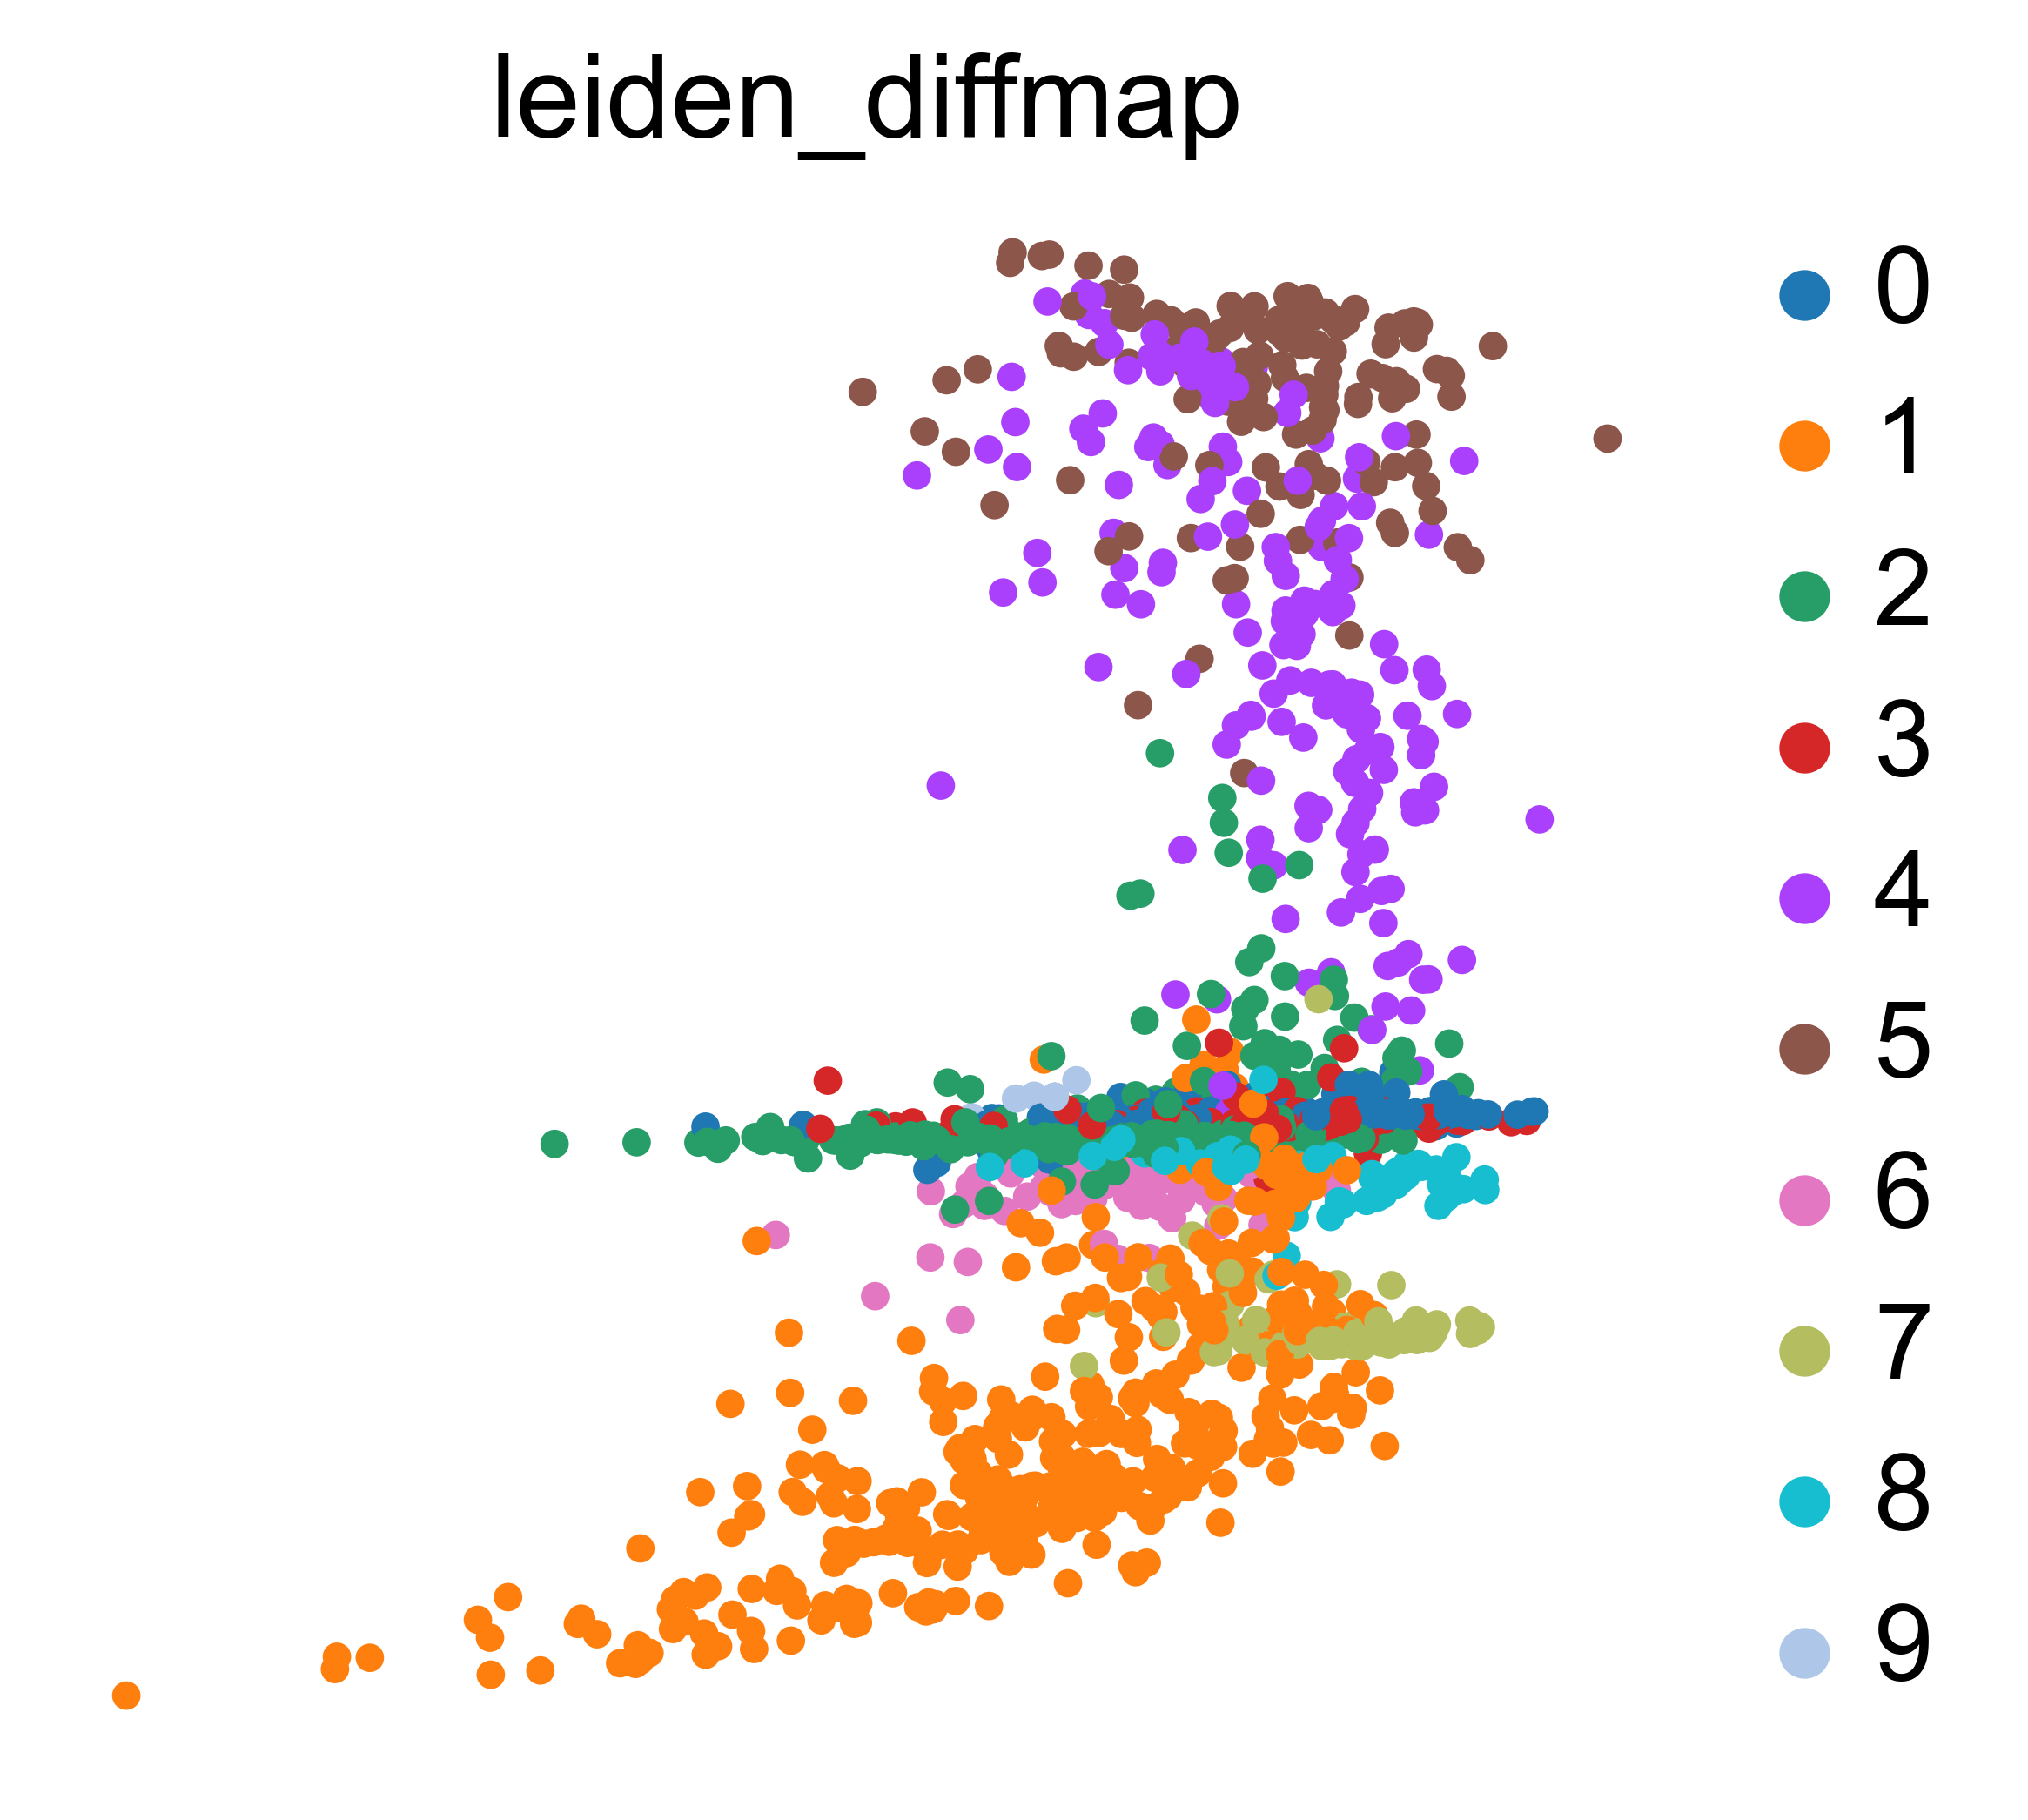

In [ ]:
sc.pl.diffmap(
    adata,
    components=["1,3"],
    color="leiden_diffmap"
)